<a href="https://colab.research.google.com/github/dearmahmud/MedVisionPipeline/blob/main/MedGemma_practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MedGemma Practice**

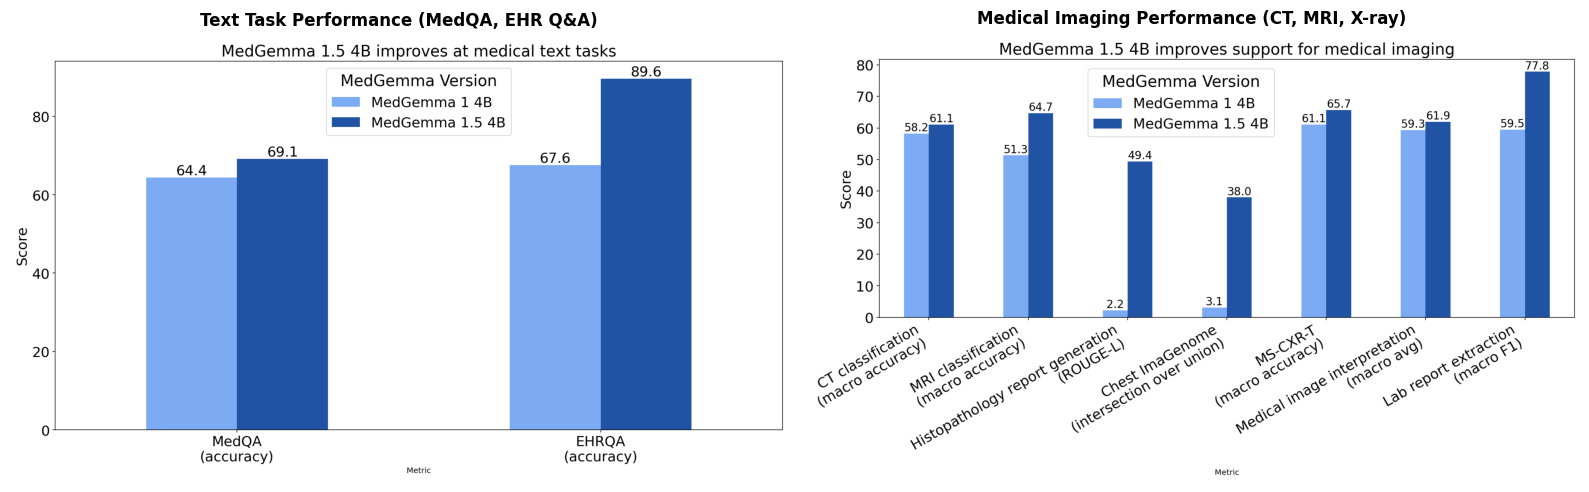


📊 Source: Google Research Blog - MedGemma 1.5 Release
   https://research.google/blog/next-generation-medical-image-interpretation-with-medgemma-15-and-medical-speech-to-text-with-medasr/

✨ Key Improvements (v1.0 → v1.5):
   • MRI classification: +14% (51% → 65%)
   • CT classification: +3% (58% → 61%)
   • Medical Q&A (MedQA): +5% (64% → 69%)
   • EHR question-answering: +22% (68% → 90%)
   • Anatomical localization: +35% (3% → 38% IOU)

🎯 vs GPT-4: Fine-tuned MedGemma achieves 80.4% vs GPT-4's 69.6% on medical imaging tasks


In [1]:
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

# Display official benchmark images from Google Research
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Text Performance Benchmarks
text_url = "https://storage.googleapis.com/gweb-research2023-media/original_images/MedGemma15-6-Text.png"
text_img = Image.open(BytesIO(requests.get(text_url).content))
ax1.imshow(text_img)
ax1.axis('off')
ax1.set_title('Text Task Performance (MedQA, EHR Q&A)', fontsize=12, fontweight='bold', pad=10)

# Imaging Performance Benchmarks
imaging_url = "https://storage.googleapis.com/gweb-research2023-media/original_images/MedGemma15-4-Imaging.png"
imaging_img = Image.open(BytesIO(requests.get(imaging_url).content))
ax2.imshow(imaging_img)
ax2.axis('off')
ax2.set_title('Medical Imaging Performance (CT, MRI, X-ray)', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

# Source citation
print("\n📊 Source: Google Research Blog - MedGemma 1.5 Release")
print("   https://research.google/blog/next-generation-medical-image-interpretation-with-medgemma-15-and-medical-speech-to-text-with-medasr/")
print("\n✨ Key Improvements (v1.0 → v1.5):")
print("   • MRI classification: +14% (51% → 65%)")
print("   • CT classification: +3% (58% → 61%)")
print("   • Medical Q&A (MedQA): +5% (64% → 69%)")
print("   • EHR question-answering: +22% (68% → 90%)")
print("   • Anatomical localization: +35% (3% → 38% IOU)")
print("\n🎯 vs GPT-4: Fine-tuned MedGemma achieves 80.4% vs GPT-4's 69.6% on medical imaging tasks")

## Installation

Install required packages:

In [2]:
!pip install -q transformers pillow torch matplotlib requests huggingface_hub

## Setup

Import libraries and load the MedGemma 1.5 model. The model is about 8GB, so first download takes a few minutes.

**Note**: The cell checks if the model is already loaded to prevent Out of Memory errors when re-running. To force reload: `del pipe` then `torch.cuda.empty_cache()`

In [3]:
import os
import getpass
from huggingface_hub import login

hf_token = getpass.getpass("Enter your Hugging Face token: ")
login(token=hf_token)

Enter your Hugging Face token: ··········


In [4]:
from transformers import pipeline
from PIL import Image
import requests
import torch
import matplotlib.pyplot as plt

# Check if model is already loaded to avoid OOM errors
if 'pipe' not in globals():
    # Load the 4B instruction-tuned model
    pipe = pipeline(
        "image-text-to-text",
        model="google/medgemma-1.5-4b-it",
        torch_dtype=torch.bfloat16,
        device="cuda" if torch.cuda.is_available() else "cpu",
        token=os.environ.get("HF_TOKEN"),  # Pass token for gated model
    )
    print(f"✓ Model loaded on: {pipe.device}")
else:
    print(f"✓ Model already loaded on: {pipe.device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


OSError: You are trying to access a gated repo.
Make sure to have access to it at https://huggingface.co/google/medgemma-1.5-4b-it.
403 Client Error. (Request ID: Root=1-69c3ba2a-1fe12955442dc4b476f7f012;e8364c4f-69ac-4213-b6bc-d126ba83f488)

Cannot access gated repo for url https://huggingface.co/google/medgemma-1.5-4b-it/resolve/main/config.json.
Access to model google/medgemma-1.5-4b-it is restricted and you are not in the authorized list. Visit https://huggingface.co/google/medgemma-1.5-4b-it to ask for access.

## Demo: Chest X-ray Analysis

We'll analyze a chest X-ray to demonstrate MedGemma's multimodal capabilities.

### Load Sample Image

Using a public domain chest X-ray from Wikipedia:

In [ ]:
# Load chest X-ray image
image_url = "https://upload.wikimedia.org/wikipedia/commons/c/c8/Chest_Xray_PA_3-8-2010.png"
image = Image.open(requests.get(image_url, headers={"User-Agent": "tutorial"}, stream=True).raw)

# Display the image
plt.figure(figsize=(8, 8))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.title('Chest X-ray PA View')
plt.show()

### Task 1: General Description

Ask the model to describe what it sees in the X-ray:

In [ ]:
# Create multimodal input (image + text)
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Describe this chest X-ray. What do you see?"}
        ]
    }
]

# Run inference
output = pipe(text=messages, max_new_tokens=500)
print("Model Response:")
print(output[0]["generated_text"][-1]["content"])

### Task 2: Disease Classification

Ask for specific clinical findings:

In [ ]:
# Ask about specific conditions
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Are there any signs of pneumonia, cardiomegaly, or pleural effusion in this chest X-ray? Provide a detailed analysis."}
        ]
    }
]

output = pipe(text=messages, max_new_tokens=500)
print("Disease Analysis:")
print(output[0]["generated_text"][-1]["content"])

### Task 3: Anatomical Localization

Identify anatomical structures and their locations:

In [ ]:
# Ask for anatomical analysis
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": "Identify and describe the location of the heart, lungs, and any abnormalities in this chest X-ray."}
        ]
    }
]

output = pipe(text=messages, max_new_tokens=500)
print("Anatomical Analysis:")
print(output[0]["generated_text"][-1]["content"])